In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import normalize
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

In [158]:
def removeNaNs(X, y):
    tmp = pd.notna(X)
    for row in range(len(X)):
        for x in tmp.iloc[row]:
            if x is False:
                X = X.drop(row)
                y = y.drop(row)
                break
            
    return X, y

In [266]:
def plot_roc_curve(fpr, tpr):
    auc = np.trapz(tpr, x=fpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'model AUC = {auc:.2f}')
    plt.plot([0,1],[0,1], "r--", label="random classifier")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.legend()    
    plt.show()
    
def plot_confusion_matrix(prediction, Y_true):
    plt.figure()
    hist, xedge, yedge, im = plt.hist2d(Y_true, prediction, bins=(2,2), range=[[0,1],[0,1]])
    plt.xlabel("Truth label")
    plt.ylabel("Predicted label")
    plt.xticks(ticks=[0.25,0.75], labels=[0, 1])
    plt.yticks(ticks=[0.25,0.75], labels=[0, 1])
    for i in range(len(xedge)-1):
        for j in range(len(yedge)-1):
            plt.text(xedge[i]+0.25, yedge[j]+0.25, hist[i,j], 
                     backgroundcolor="white", color="black", weight="bold",
                     ha="center", va="center")
    plt.colorbar()
    plt.show()
    
def roc_curve(model, X_test, Y_test):
    tot_pos = sum(Y_test)
    tot_neg = len(Y_test) - tot_pos
    prediction = model.predict(X_test)
    predict_probs = model.predict_proba(X_test)
    fpr = [] 
    tpr = []
    for threshold in np.arange(0., 1.01, 0.01):
        tps = (predict_probs[:,1] >= threshold) * (Y_test==1)
        fps = (predict_probs[:,1] >= threshold) *  (Y_test==0)
        
        tpr.append(sum(tps) / tot_pos)
        fpr.append(sum(fps) / tot_neg)
        
    tpr.reverse()
    fpr.reverse()
    plot_roc_curve(fpr, tpr)
    plot_confusion_matrix(prediction, Y_test)
    
    return prediction, fpr, tpr

In [259]:
titanic = fetch_openml(data_id=40945)
data = titanic.data[["pclass","sex", "age", "sibsp", "parch", "fare"]]
target = titanic.target.astype("int32")

In [250]:
data["sex"] = data["sex"].cat.rename_categories([1, 0])
data, target = removeNaNs(data, target)

/var/folders/8y/lxd4m2nx5y750shcys1g9dqm0013cl/T/ipykernel_84178/2701855754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["sex"] = data["sex"].cat.rename_categories([1, 0])


In [251]:
X_train, X_test, Y_train, Y_test = train_test_split(data, target, random_state=42)

In [252]:
## Different Models for testing
LSVC = LinearSVC()

_SVC = SVC()

RF_classifier = RandomForestClassifier(n_estimators=150, max_samples=0.1, criterion="log_loss", max_depth=3, 
                                       min_samples_split=10, random_state=42)

In [253]:
## Looking at boosting
weak_learner = DecisionTreeClassifier(max_leaf_nodes=8)
n_estimators = 300

adaboost_clf = AdaBoostClassifier(
    estimator=weak_learner,
    n_estimators=n_estimators,
    random_state=42,
)

In [254]:
LSVC.fit(X_train, Y_train)
LSVC.score(X_test, Y_test)

0.732824427480916

In [255]:
RF_classifier.fit(X_train, Y_train)

RandomForestClassifier(criterion='log_loss', max_depth=3, max_samples=0.1,
                       min_samples_split=10, n_estimators=150, random_state=42)

In [256]:
_SVC.fit(X_train, Y_train)
_SVC.score(X_test, Y_test)

0.6603053435114504

In [257]:
adaboost_clf.fit(X_train, Y_train)
adaboost_clf.score(X_test, Y_test)

0.7442748091603053

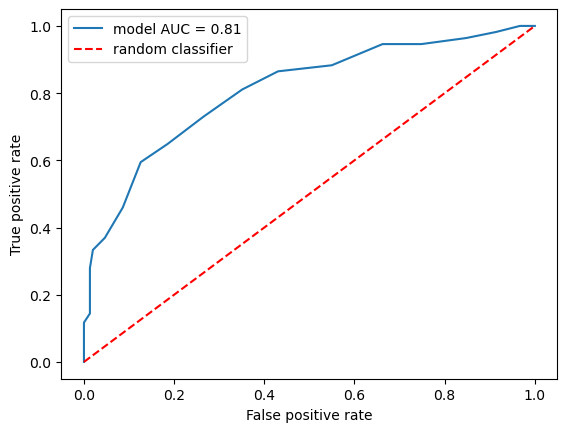

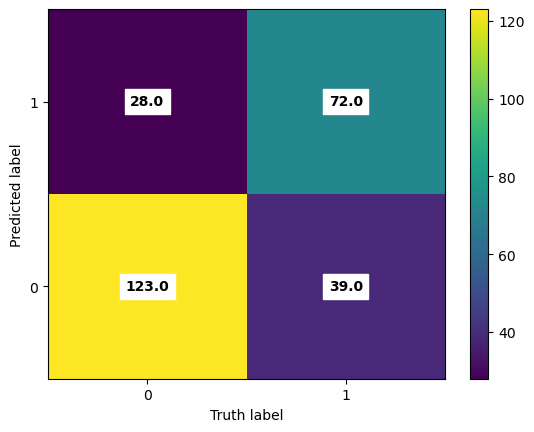

In [269]:
prediction, fpr, tpr = roc_curve(adaboost_clf, X_test, Y_test)